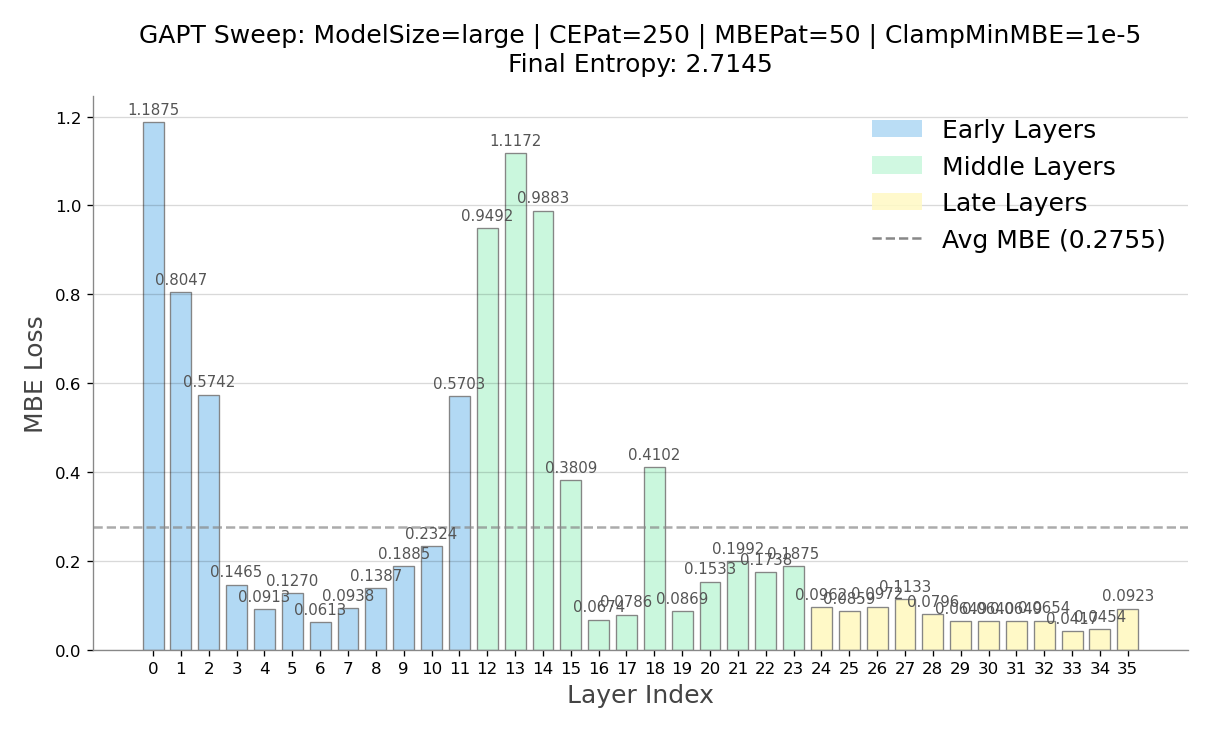

In [4]:
# Analysis on log runs 
from src.utils import *

# ----- IBLM ----- 
log_path = "logs/gpt2-large-iblm.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])

# --- visualize dynamics ---
frames = []
for i in range(len(loss_record["entropy"])):
    if i % 1 == 0: # Optional: skip frames for speed
        print(f"Rendering frame {i}/{len(loss_record['entropy'])}", end='\r')
        frames.append(create_training_frame(i, loss_record, run_info=run_info, n_layer=n_layer))

frames[0].save(
    f"mbe_dynamics_{run_info}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=100, # ms per frame
    loop=0
)

# --- visualize final losses ---
visualize_final_losses(loss_record, run_info=run_info, n_layer=n_layer)

In [5]:
len(loss_record["entropy"])

65

In [2]:
{k: loss_record[k][-1]for k in loss_record}

{'mbe_0': 0.88671875,
 'mbe_1': 0.7265625,
 'mbe_2': 0.546875,
 'mbe_3': 0.09375,
 'mbe_4': 0.061279296875,
 'mbe_5': 0.033447265625,
 'mbe_6': 0.03857421875,
 'mbe_7': 0.05419921875,
 'mbe_8': 0.06591796875,
 'mbe_9': 0.10693359375,
 'mbe_10': 0.30859375,
 'mbe_11': 0.85546875,
 'mbe_12': 0.9453125,
 'mbe_13': 0.7890625,
 'mbe_14': 0.5078125,
 'mbe_15': 0.0908203125,
 'mbe_16': 0.224609375,
 'mbe_17': 1.0390625,
 'mbe_18': 1.1640625,
 'mbe_19': 1.125,
 'mbe_20': 1.328125,
 'mbe_21': 1.421875,
 'mbe_22': 1.3046875,
 'mbe_23': 0.9921875,
 'mbe_24': 1.015625,
 'mbe_25': 0.74609375,
 'mbe_26': 0.7578125,
 'mbe_27': 0.76953125,
 'mbe_28': 0.7265625,
 'mbe_29': 0.65625,
 'mbe_30': 0.55078125,
 'mbe_31': 0.5703125,
 'mbe_32': 0.0927734375,
 'mbe_33': 0.1015625,
 'mbe_34': 0.09130859375,
 'mbe_35': 0.0966796875,
 'mbe_36': 0.099609375,
 'mbe_37': 0.10009765625,
 'mbe_38': 0.09814453125,
 'mbe_39': 0.0966796875,
 'mbe_40': 0.072265625,
 'mbe_41': 0.06982421875,
 'mbe_42': 0.07421875,
 'mbe_43'

In [19]:
# --- Total hours required to pre-train on 10B tokens ---
tok_per_batch = (32 * 16 * 1024)
total_tok = 10 * 10**9
num_epoch = 1
steps = (num_epoch * total_tok) / tok_per_batch
ms_per_step = 5619 
total_hours = steps * ms_per_step / 1000 / 60 / 60

total_hours

29.770533243815105

In [42]:
# Issue #1. Rotation adopting 'skip_last=1' -> last few layer MBE very low
#           this is not ideal, we want mid-layer to be compressed more


In [1]:
from sorl.stat import extract_log_data

# ----- SoRL ----- 
log_path = "logs/sorl-21.txt"

# --- extract log data ---
run_info, loss_record = extract_log_data(log_path)
n_layer = len([k for k in loss_record.keys() if 'mbe_' in k])
if "attn sweep" not in run_info:
    run_info += " + attn_sweep" 

# --- visualize dynamics --- 
# (1). x-axis: step, y-axis: search info gain, util rate, search adv, cond_traj_loss, base_traj_loss 
#     group some of them together (cond_traj_loss, base_traj_loss) (search info gain, search adv), util rate
#     3 rows 1 column, make a gif plot out

{k: loss_record[k][-1]for k in loss_record}

{'base_traj_loss': 1.0347,
 'cond_traj_loss (greedy)': 1.0509,
 'abs_loss (greedy)': 0.7554,
 'greedy_adv': 0.0984,
 'info_gain (greedy)': -0.0125,
 'util_rate': 0.4675,
 'K': 8.0}

In [2]:
from sorl.stat import generate_sorl_dynamics_gif

generate_sorl_dynamics_gif(loss_record, "logs/k_curriculum_dynamics.gif", run_info, val_interval=125, fps=5)

ValueError: min() iterable argument is empty